### YOLO Training – Table Detection

##### Confirm GPU is detected:

In [1]:
from ultralytics import YOLO
import torch

print("GPU available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

GPU available: True
CUDA device name: NVIDIA RTX 2000 Ada Generation Laptop GPU


##### Train YOLOv8

In [2]:
from ultralytics import YOLO

# Load model (pretrained weights)
model = YOLO("yolov8s.pt")

# Train
model.train(
    data="../data/dataset.yaml",    # dataset config
    epochs=100,                     # adjust depending on dataset size
    imgsz=640,                      # YOLO image size (resize)
    batch=16,                       # adjust according to GPU memory
    device=0,                       # 0 = first GPU, 'cpu' for CPU
    project="../runs/train",        # output folder
    name="table_detection",
    exist_ok=True,                  # overwrite if same name
    patience=10,                    # Early stopping patience (epochs with no improvement)
    save_period=1                   # Save weights every epoch
)

print("Completed !")

New https://pypi.org/project/ultralytics/8.4.19 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.235  Python-3.11.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=table_detection, nb

2026/03/03 23:19:07 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2026/03/03 23:19:07 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.


MLflow: logging run_id(6df9ec61dd1445868fe7ede9ee2464bc) to runs\mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs\mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to C:\Users\anass\Desktop\Fluxia\runs\train\table_detection
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      3.65G      1.227      2.501      1.441         34        640: 100% ━━━━━━━━━━━━ 37/37 2.0it/s 18.6s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.6it/s 1.8s1.3s
                   all         74         89      0.819      0.629      0.764      0.424

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      2/100       3.7G      1.343      1.319      1.507         22        640: 100% ━━━━━━━━━━━━ 37/37 2.6it/s 14.3s0.4s

##### Evaluate on Test Set

In [3]:
metrics = model.val(data="../data/dataset.yaml", split="test")

for key, value in metrics.results_dict.items():
    print(f"{key :25s} -", value)

Ultralytics 8.3.235  Python-3.11.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA RTX 2000 Ada Generation Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access  (ping: 0.50.4 ms, read: 32.951.2 MB/s, size: 366.4 KB)
val: Scanning C:\Users\anass\Desktop\Fluxia\data\processed\yolo_dataset\labels\test... 74 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 74/74 238.1it/s 0.3s0.2s
val: New cache created: C:\Users\anass\Desktop\Fluxia\data\processed\yolo_dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.8s/it 14.1s0.4s6
                   all         74         80      0.974      0.988      0.987      0.753
Speed: 3.7ms preprocess, 11.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to C:\Users\anass\Desktop\Fluxia\notebooks\runs\detect\val3
metrics/precision(B)      - 0.9743032565320581
metrics/recall(B)         - 0.9875


##### Visualize Predictions

In [4]:
import os
import cv2
import matplotlib.pyplot as plt


TEST_DIR = "../data/processed/yolo_dataset/images/test/"

test_img_list = os.listdir(TEST_DIR)

random_pictures = list(map(lambda img: TEST_DIR + img, test_img_list[:6]))



0: 640x640 1 table, 13.7ms
1: 640x640 1 table, 13.7ms
2: 640x640 1 table, 13.7ms
3: 640x640 1 table, 13.7ms
4: 640x640 (no detections), 13.7ms
5: 640x640 1 table, 13.7ms
Speed: 5.1ms preprocess, 13.7ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


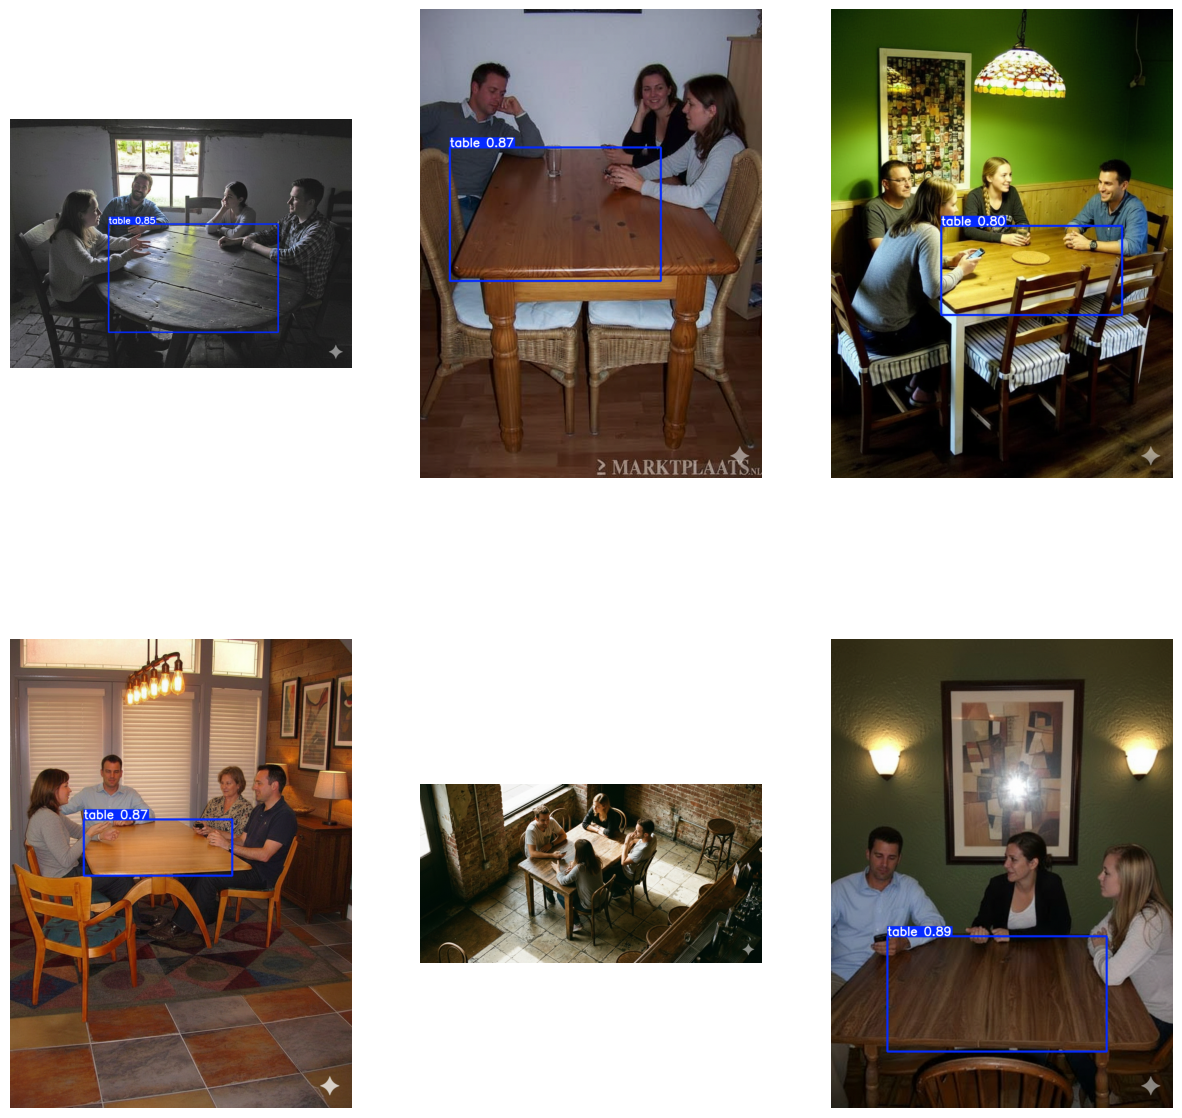

In [5]:
%matplotlib inline

results = model.predict(random_pictures, conf=0.5)

plt.figure(figsize=(15, 15))
plt.tight_layout()

for index, r in enumerate(results, 1):
    img = r.plot()
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, index)
    plt.imshow(img_rgb)
    plt.axis('off')
plt.show()